# 03 · Policy: what happened when the climate bonus ended?

**Business question:** How fast is Sweden shifting to battery-electric cars among private buyers, where is it fastest or slowest and why, and what BEV share is plausible by 2028?

This notebook covers the *why* over time: the effect of ending the climate bonus (klimatbonus) on **8 Nov 2022** on the private BEV share. It answers four questions raised in 01 and 02:
1. Was the change an **immediate drop**, a **change in trend**, or both?
2. How big was the **rush** before the deadline, and how much of the 2023 decline does it explain?
3. Why did **company buyers** behave differently?
4. Did **sparsely populated counties** react more strongly, as 02 suggested?

**Policy timeline** (context only, not taken from the data):
- **Jul 2018:** bonus–malus system introduced.
- **1 Apr 2021:** bonus rules revised, with a higher maximum bonus.
- **8 Nov 2022:** bonus abolished.
- The exact eligibility rules around the deadline (order date vs registration date) matter for how the Nov–Dec 2022 months should be read. They should be checked against the regulation before any month-level claim is cited.

## 1. Setup and design

**Method: interrupted time series (ITS), estimated as a segmented regression.**

$$y_t = \beta_0 + \beta_1 t + \beta_2\,\text{post}_t + \beta_3\,(t - T_0)\,\text{post}_t + \text{month-of-year}_t + \text{transition}_t + \varepsilon_t$$

- $y_t$ = monthly private BEV share (pp), $t$ = months since the start.
- $\beta_1$ = bonus-era trend. $\beta_2$ = **level change** at $T_0$ = Jan 2023. $\beta_3$ = **slope change** after $T_0$.
- **Month-of-year dummies** handle the strong seasonality found in 01 (Sep and Dec spikes). They're estimated on both periods together.
- **Transition months** each get their own dummy. That's equivalent to leaving them out of the trend fit, and their coefficients measure the "rush" above the pre-trend.

**Windows, and the reasons for them:**
- **Pre-period: Apr 2021 – Aug 2022** (17 months). Jan–Mar 2021 is left out: the share was 6–7% and jumped to 20% in April, which coincides with the bonus revision of 1 April 2021. Buyers likely waited, so those months belong to a different policy regime.
- **Transition: Sep – Dec 2022.** The build script's `pull_forward_window` is Sep–Nov. **I add December**, because Dec 2022 was 63% BEV, the highest month in the series and far above a normal December. Leaving it in the post-period would distort the post-bonus level.
- **Post-period: Jan 2023 – Aug 2026** (44 months).

**Standard errors:** Newey–West (HAC, 6 lags) as the main specification, because monthly residuals are autocorrelated. An AR(1)-error model is the main robustness check (section 4).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import viz
from viz import BLUE, ORANGE, AQUA, RED, INK, INK2, MUTED, GRID, AXIS, GREY_DARK, GREY_LIGHT, SURFACE, PCT
viz.apply_style()
PROC, FIGS = ROOT / "data" / "processed", ROOT / "docs" / "figures"

fact = pd.read_csv(PROC / "fact_registrations_county_monthly.csv", parse_dates=["month"], dtype={"county_code": str})
panel = pd.read_csv(PROC / "county_year_panel.csv", dtype={"county_code": str})

def monthly(df):
    w = df.pivot_table(index="month", columns="fuel_type", values="registrations", aggfunc="sum", fill_value=0)
    return pd.DataFrame({"bev": w["BEV"], "total": w.sum(axis=1)}).assign(share=lambda d: d.bev / d.total)

own = {o: monthly(fact[fact.owner_type == o]) for o in ["private", "company", "dealer"]}
pv = own["private"]

START, T0 = pd.Timestamp("2021-04-01"), pd.Timestamp("2023-01-01")
TRANS = pd.date_range("2022-09-01", "2022-12-01", freq="MS")
LAST = pv.index.max()
print(f"Pre: {START:%b %Y}–Aug 2022 | transition: {TRANS[0]:%b}–{TRANS[-1]:%b %Y} | post: {T0:%b %Y}–{LAST:%b %Y}")

Pre: Apr 2021–Aug 2022 | transition: Sep–Dec 2022 | post: Jan 2023–Aug 2026


## 2. Look at the data around the boundary

Before any model, the raw series. Shares are shown on the left and registration counts on the right, as two separate charts rather than two y-axes on one chart. The grey band marks the transition months.

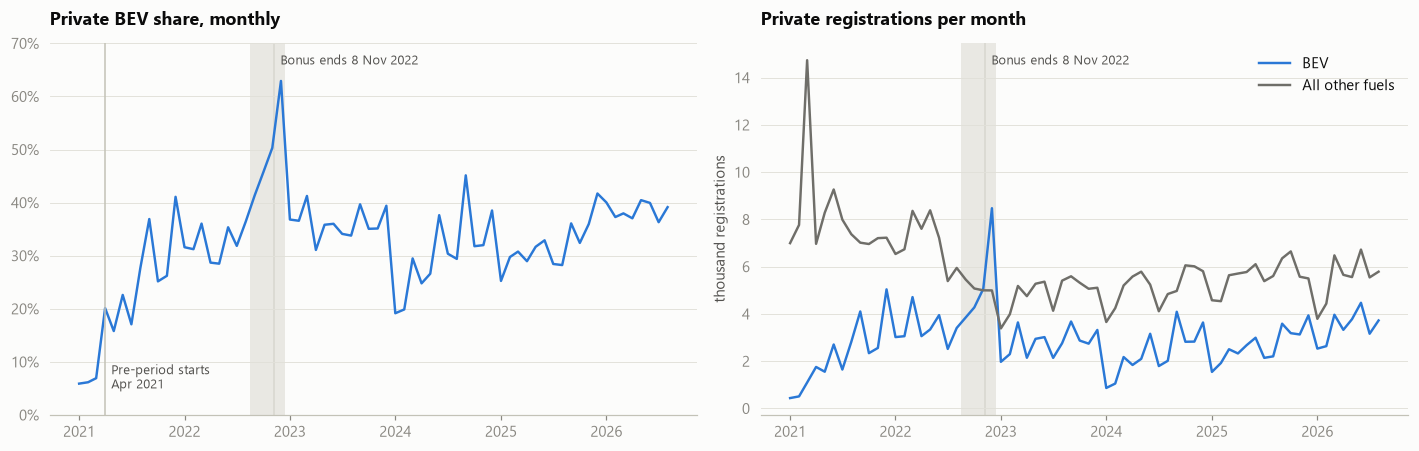

,bev,non_bev,total,share
month,,,,
May 2022,"3,342","8,385","11,727",28.5%
Jun 2022,"3,949","7,221","11,170",35.4%
Jul 2022,"2,519","5,390","7,909",31.8%
Aug 2022,"3,406","5,947","9,353",36.4%
Sep 2022,"3,848","5,457","9,305",41.4%
Oct 2022,"4,276","5,076","9,352",45.7%
Nov 2022,"5,062","4,999","10,061",50.3%
Dec 2022,"8,474","4,995","13,469",62.9%
Jan 2023,"1,973","3,387","5,360",36.8%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax in axes:
    ax.axvspan(TRANS[0] - pd.Timedelta(days=15), TRANS[-1] + pd.Timedelta(days=15), color=GRID, alpha=0.7, lw=0)
    viz.mark_bonus(ax)
ax = axes[0]
ax.plot(pv.index, pv.share, color=BLUE, lw=1.6)
ax.axvline(START, color=AXIS, lw=1)
ax.annotate("Pre-period starts\nApr 2021", (START, 0.05), xytext=(4, 0), textcoords="offset points", fontsize=8.5, color=INK2)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 0.7)
ax.set_title("Private BEV share, monthly")
ax = axes[1]
ax.plot(pv.index, pv.bev / 1000, color=BLUE, lw=1.6, label="BEV")
ax.plot(pv.index, (pv.total - pv.bev) / 1000, color=GREY_DARK, lw=1.6, label="All other fuels")
ax.set_ylabel("thousand registrations")
ax.set_title("Private registrations per month")
ax.legend(loc="upper right")
fig.tight_layout()
viz.save(fig, "03_boundary_raw", FIGS)
plt.show()

win = pv.loc["2022-05":"2023-04"].copy()
win["non_bev"] = win.total - win.bev
win.index = win.index.strftime("%b %Y")
win[["bev", "non_bev", "total", "share"]].style.format({"bev": "{:,.0f}", "non_bev": "{:,.0f}", "total": "{:,.0f}",
                                                       "share": "{:.1%}"}).set_caption("Private registrations around the boundary")

**What the raw data shows**
- The share climbs through autumn 2022 (41% → 46% → 50%) and peaks at **63% in Dec 2022**. Then it **drops to 37% in Jan 2023** and stays in the mid-30s.
- In volume, Dec 2022 is a spike in BEVs (8,474, about 2.5× a normal 2022 month), and **all private buying collapses in early 2023**: Jan 2023 had 5,360 private registrations of all fuels, against 13,469 in December. Part of the 2023 fall in share is a smaller market, as 01 showed. Non-BEV volume also fell.
- The post-2023 share has no visible trend until late 2025, unlike the steep climb before. That's what the segmented regression has to quantify.
- **March 2021** has a spike in non-BEV private registrations (about 14,700, double a normal month), just before the 1 April 2021 rule change. It's consistent with buyers bringing combustion-car purchases forward, and it's a second reason to start the pre-period in April.